## Data Understanding and Preprocessing 
Pandas: For data manipulation and cleaning.
Matplotlib: to plot the graph
Seaborn: 
SciPy: performing statistical calculations

In [6]:
#libraries and Data loading
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

df = pd.read_csv("WEATHER_REPORTS.CSV")

## Data Cleaning  
# Clean column names
# datetime index
# Refrencing precipitation column
# Remove rows with NaNs in critical columns

In [7]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w\s]', '', regex=True)

df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df.set_index('date', inplace=True)

df.rename(columns={'merra2_precipitation_corrected_mmday': 'precip'}, inplace=True)

# Remove rows with NaNs in critical columns
df = df.dropna(subset=['precip', 'latitude', 'longitude'])


## Feature Engineering 

In [8]:
# Group data by location and month
monthly_precip_by_location = df.groupby(['latitude', 'longitude'])['precip'].resample('M').sum().reset_index()

# Define SPI-6 calculation using rolling sum and z-score
def compute_spi_group(group):
    group = group.sort_values('date')
    group['rolling_6'] = group['precip'].rolling(window=6).sum()
    group['spi_6'] = zscore(group['rolling_6'], nan_policy='omit')
    return group

# Apply SPI computation to each location
spi6_data = monthly_precip_by_location.groupby(['latitude', 'longitude']).apply(compute_spi_group).reset_index(drop=True)


C:\Users\469775\AppData\Local\Temp\ipykernel_4308\2691809548.py:2: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\469775\AppData\Local\Temp\ipykernel_4308\2691809548.py:12: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



## Model Interpretation and Deployment 

In [10]:
# Compute mean SPI-6 per region
spi6_region_avg = spi6_data.groupby(['latitude', 'longitude'])['spi_6'].mean().reset_index()

# Classify regions by drought severity
def classify_spi_region(avg_spi):
    if avg_spi <= -2:
        return 'Extremely Dry'
    elif avg_spi <= -1.5:
        return 'Severely Dry'
    elif avg_spi <= -1.0:
        return 'Moderately Dry'
    elif avg_spi <= 0.99:
        return 'Near Normal'
    elif avg_spi <= 1.49:
        return 'Moderately Wet'
    elif avg_spi <= 1.99:
        return 'Very Wet'
    else:
        return 'Extremely Wet'

# Apply classification
spi6_region_avg['category'] = spi6_region_avg['spi_6'].apply(classify_spi_region)


## Choosing Algorithms and Feature Selection 
SPI-6 is chosen as the climate drought index.

Feature selection is based on precipitation and geolocation (latitude, longitude).

C:\Users\469775\AppData\Local\Temp\ipykernel_4308\3021793271.py:17: UserWarning:

Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.

C:\Users\469775\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.



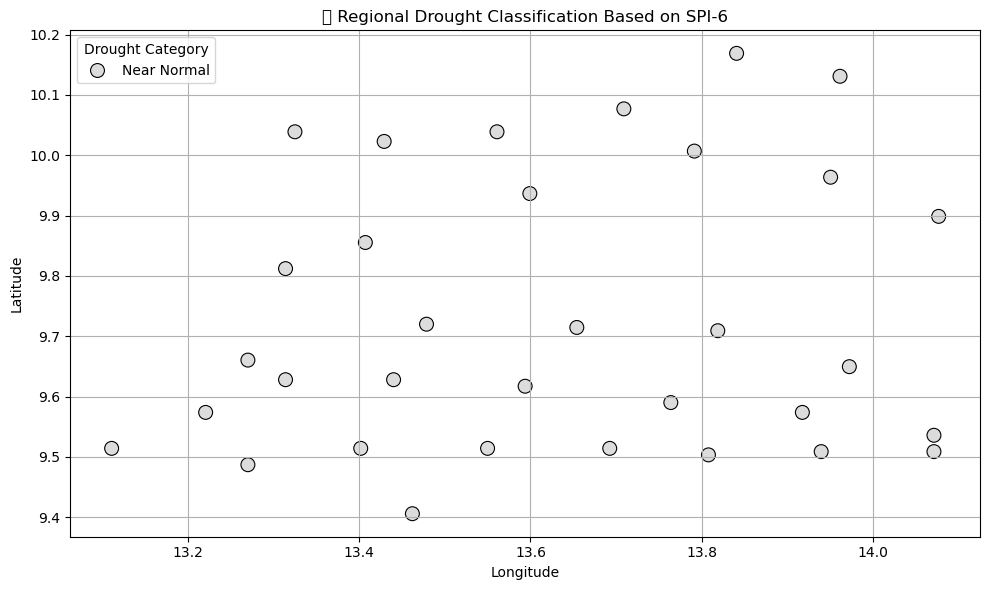

In [11]:
# Plot classified regions on a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=spi6_region_avg,
    x='longitude',
    y='latitude',
    hue='category',
    palette='coolwarm',
    s=100,
    edgecolor='black'
)
plt.title('📍 Regional Drought Classification Based on SPI-6')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.legend(title='Drought Category')
plt.tight_layout()
plt.show()
